In [11]:
import os

print(os.path.exists("../data/superstore.xls"))
print(os.path.getsize("../data/superstore.xls"))

True
2287806


In [12]:
with open("../data/superstore.xls", "rb") as f:
    print(f.read(20))

b'Row ID,Order ID,Orde'


In [13]:
import pandas as pd

try:
    df = pd.read_excel("../data/superstore.xls", engine="xlrd")
    print("Loaded with xlrd")
except Exception as e:
    print("ERROR:")
    print(type(e))
    print(e)

ERROR:
<class 'xlrd.biffh.XLRDError'>
Unsupported format, or corrupt file: Expected BOF record; found b'Row ID,O'


In [15]:
import pandas as pd

df = pd.read_csv("../data/superstore.xls", encoding="latin1")

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [16]:
print(df.shape)

(9994, 21)


In [17]:
print(df.columns.tolist())

['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']


In [18]:
df.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

In [19]:
print("Duplicates:", df.duplicated().sum())

Duplicates: 0


In [20]:
df.drop_duplicates(inplace=True)

print("Duplicates After Removal:", df.duplicated().sum())

Duplicates After Removal: 0


In [21]:
df["Order Date"] = pd.to_datetime(df["Order Date"])
df["Ship Date"] = pd.to_datetime(df["Ship Date"])

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9994 non-null   int64         
 1   Order ID       9994 non-null   str           
 2   Order Date     9994 non-null   datetime64[us]
 3   Ship Date      9994 non-null   datetime64[us]
 4   Ship Mode      9994 non-null   str           
 5   Customer ID    9994 non-null   str           
 6   Customer Name  9994 non-null   str           
 7   Segment        9994 non-null   str           
 8   Country        9994 non-null   str           
 9   City           9994 non-null   str           
 10  State          9994 non-null   str           
 11  Postal Code    9994 non-null   int64         
 12  Region         9994 non-null   str           
 13  Product ID     9994 non-null   str           
 14  Category       9994 non-null   str           
 15  Sub-Category   9994 non-null   s

In [22]:
df.describe()

,Row ID,Order Date,Ship Date,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994,9994,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,2016-04-30 00:07:12.259355,2016-05-03 23:06:58.571142,55190.379428,229.858001,3.789574,0.156203,28.656896
min,1.000000,2014-01-03 00:00:00,2014-01-07 00:00:00,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,2015-05-23 00:00:00,2015-05-27 00:00:00,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,2016-06-26 00:00:00,2016-06-29 00:00:00,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,2017-05-14 00:00:00,2017-05-18 00:00:00,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,2017-12-30 00:00:00,2018-01-05 00:00:00,99301.000000,22638.480000,14.000000,0.800000,8399.976000
std,2885.163629,NaN,NaN,32063.693350,623.245101,2.225110,0.206452,234.260108


In [23]:
Q1 = df["Sales"].quantile(0.25)
Q3 = df["Sales"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df_clean = df[
    (df["Sales"] >= lower) &
    (df["Sales"] <= upper)
]

print("Original Shape:", df.shape)
print("After Removing Outliers:", df_clean.shape)

Original Shape: (9994, 21)
After Removing Outliers: (8827, 21)


In [24]:
df_clean.to_csv(
    "../data/cleaned_superstore.csv",
    index=False
)

print("Cleaned Dataset Saved")

Cleaned Dataset Saved


In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("default")

Matplotlib is building the font cache; this may take a moment.


In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("default")

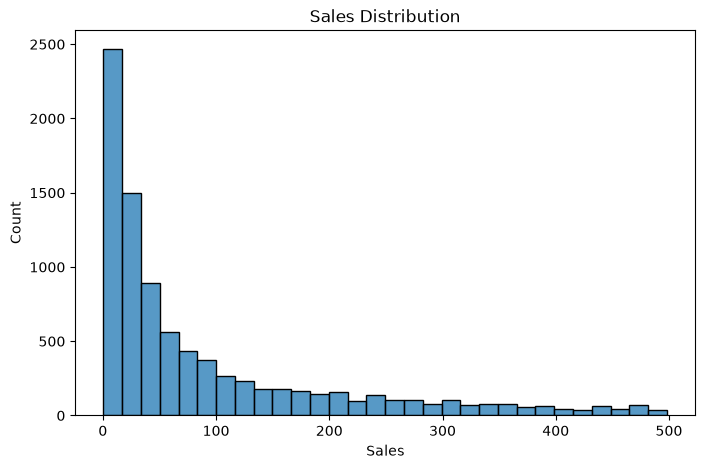

In [27]:
plt.figure(figsize=(8,5))

sns.histplot(df_clean["Sales"], bins=30)

plt.title("Sales Distribution")

plt.show()

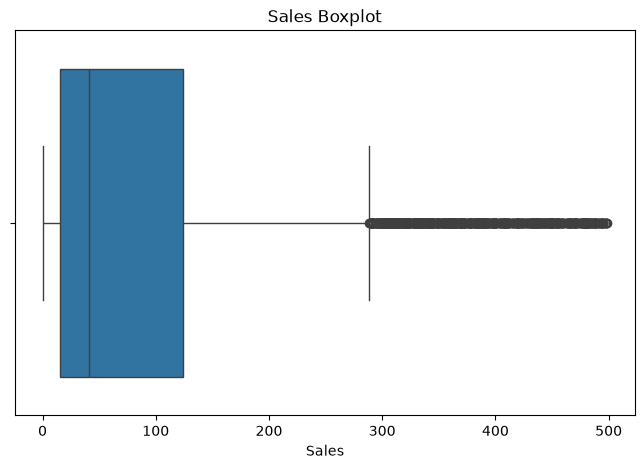

In [28]:
plt.figure(figsize=(8,5))

sns.boxplot(x=df_clean["Sales"])

plt.title("Sales Boxplot")

plt.show()

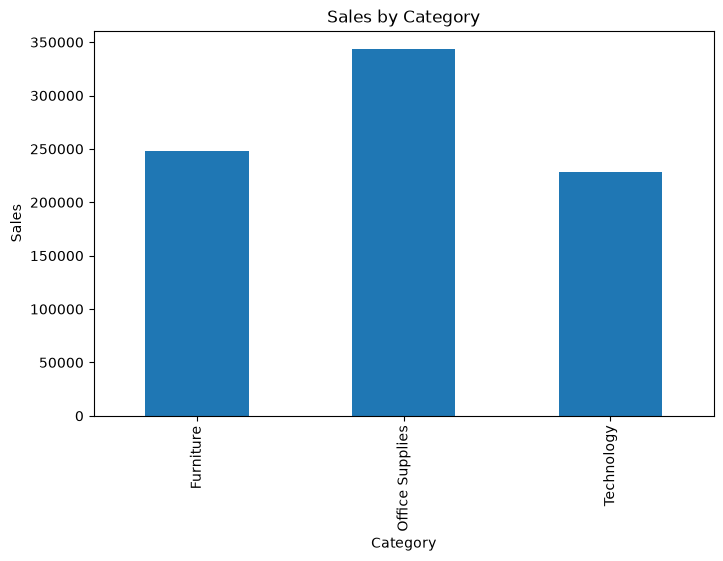

In [29]:
plt.figure(figsize=(8,5))

df_clean.groupby("Category")["Sales"].sum().plot(
    kind="bar"
)

plt.title("Sales by Category")
plt.ylabel("Sales")

plt.show()

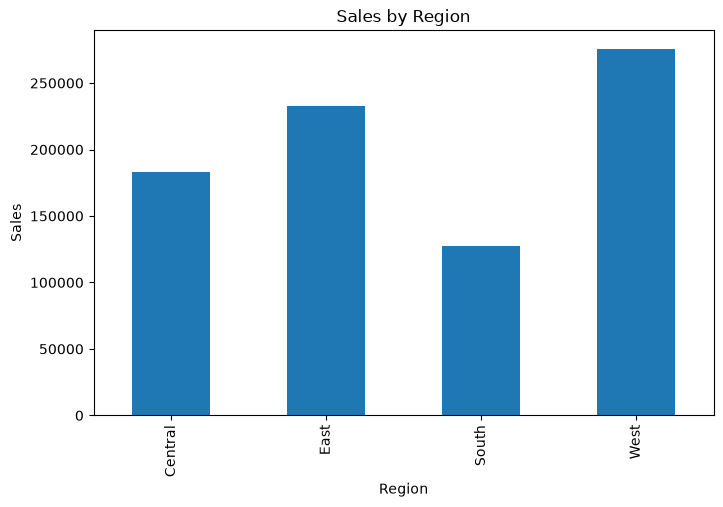

In [30]:
plt.figure(figsize=(8,5))

df_clean.groupby("Region")["Sales"].sum().plot(
    kind="bar"
)

plt.title("Sales by Region")
plt.ylabel("Sales")

plt.show()

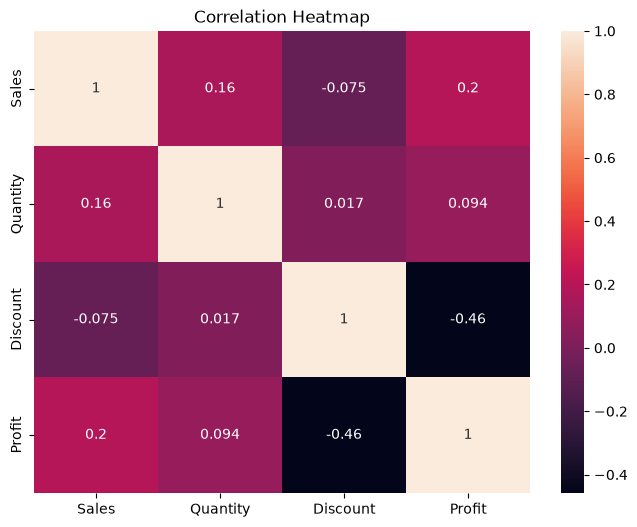

In [31]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df_clean[
        ["Sales","Quantity","Discount","Profit"]
    ].corr(),
    annot=True
)

plt.title("Correlation Heatmap")

plt.show()

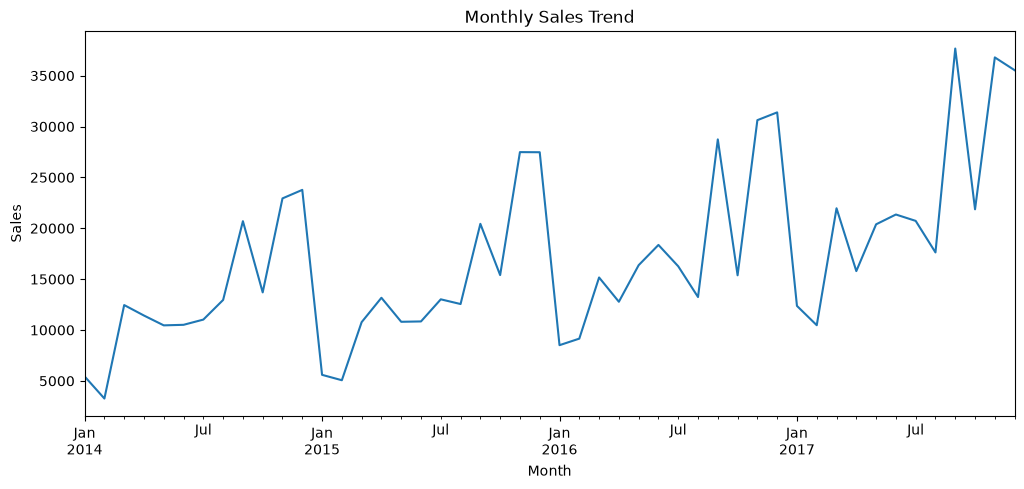

In [32]:
monthly_sales = df_clean.groupby(
    df_clean["Order Date"].dt.to_period("M")
)["Sales"].sum()

monthly_sales.plot(
    figsize=(12,5)
)

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")

plt.show()

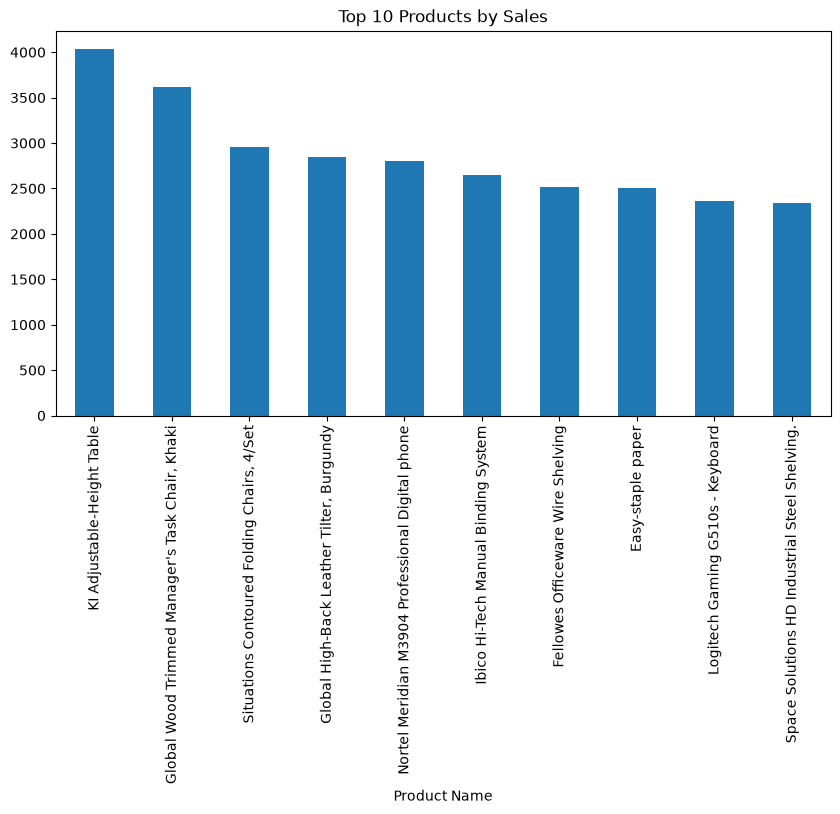

In [33]:
top_products = (
    df_clean.groupby("Product Name")["Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,5))

top_products.plot(kind="bar")

plt.title("Top 10 Products by Sales")

plt.show()

KEY INSIGHTS

1. Technology category generates the highest sales among all categories.

2. Sales are concentrated among a small set of top-performing products.

3. Most orders fall within lower sales ranges, with a few high-value transactions.

4. Sales show noticeable fluctuations across different months.

5. Profit generally increases with sales, while discounts can negatively impact profitability.

# Conclusion

The Superstore dataset was cleaned and analyzed successfully.

Data cleaning included handling missing values, removing duplicates, converting date columns, and removing outliers using the IQR method.

Exploratory Data Analysis revealed sales patterns, category performance, regional trends, and relationships between sales, discounts, and profit.

This analysis provides useful business insights for decision-making.

In [34]:
df_clean.to_csv("../data/cleaned_superstore.csv", index=False)

print("Cleaned dataset saved successfully")

Cleaned dataset saved successfully
